## SGD manual

In [25]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt


X_b, y = load_wine(return_X_y = True)


print(X_b.min())
print(X_b.max())

X_b = StandardScaler().fit_transform(X_b)
print(y.shape)
y = y.reshape(-1,1)
print(y.shape)
#y = y.reshape(1, -1)
#print(y.shape) (1,178)

0.13
1680.0
(178,)
(178, 1)


In [49]:

m = X_b.shape[0]

n_epochs = 50
t0, t1 = 5, 50

def learning_schedule(t):
    return t0 / (t + t1)

rng = np.random.default_rng(seed=42)
theta = rng.standard_normal((13,1))
gradient_history = []
gr_norm = []
for epoch in range(n_epochs):
    for iteration in range(m):
        
        random_idx = rng.integers(m)

        x1 = X_b[random_idx:random_idx+1]
        y1 = y[random_idx:random_idx+1]

        gradients = 2 * x1.T @ (x1 @ theta - y1)

        eta = learning_schedule(epoch * m + iteration)

        theta = theta - eta * gradients
        
        gradient_history.append(gradients.flatten())

        gr_norm.append(np.linalg.norm(gradients.flatten()))

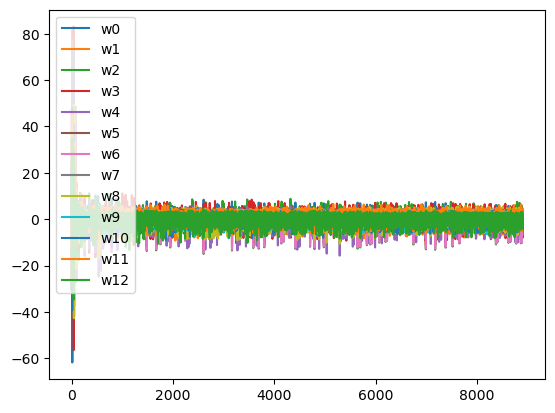

<Figure size 1200x800 with 0 Axes>

8900


<Axes: >

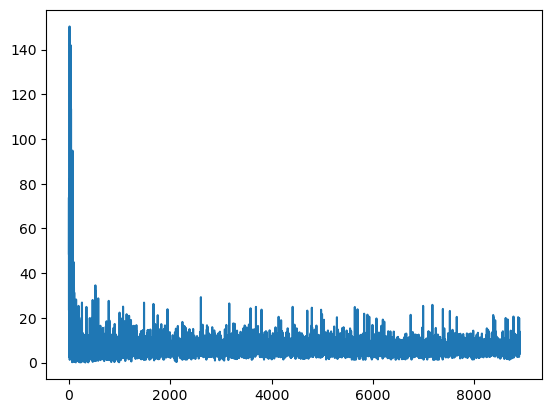

In [50]:
gradient_history = np.array(gradient_history)

for i in range(13):
    plt.plot(gradient_history[:, i], label=f"w{i}")

plt.legend()
plt.figure(figsize=(12,8))
plt.show()
print(len(gradient_history))

sns.lineplot(gr_norm)

## Polynomial Regression

In [51]:
rng = np.random.default_rng(seed=42)
m = 200 # number of instances
X = 6 * rng.random((m,1)) -3
y = 0.5 * X ** 2 + X + rng.standard_normal((m,1))

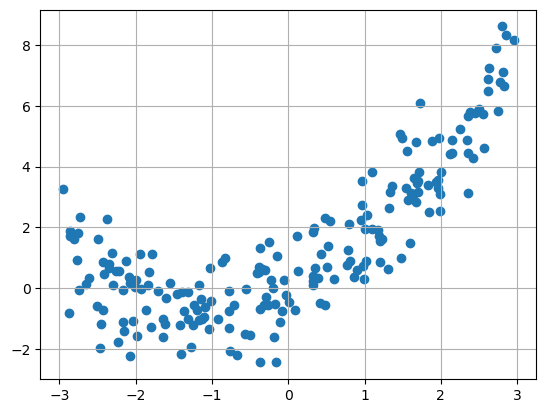

In [57]:
plt.scatter(X,y)
plt.grid()

In [59]:
from sklearn.preprocessing import PolynomialFeatures
poly_feat = PolynomialFeatures(degree = 2, include_bias = False)
X_poly = poly_feat.fit_transform(X)

print(X[1], X_poly[1])

[-0.36672936] [-0.36672936  0.13449042]


In [60]:
from sklearn.linear_model import LinearRegression

In [62]:
lin_reg  = LinearRegression()
lin_reg.fit(X_poly, y)
print(lin_reg.intercept_)
print(lin_reg.coef_)

[0.00540719]
[[1.11022126 0.50526985]]


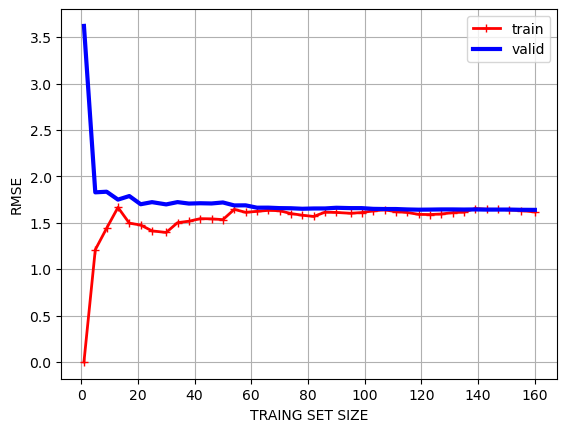

In [65]:
from sklearn.model_selection import learning_curve
train_sizes, train_scores, valid_scores = learning_curve(
LinearRegression(), X, y, train_sizes=np.linspace(0.01, 1.0, 40),
cv=5,
scoring="neg_root_mean_squared_error")
train_errors = -train_scores.mean(axis=1)
valid_errors = -valid_scores.mean(axis=1)
plt.plot(train_sizes, train_errors, "r-+", linewidth=2, label="train")
plt.plot(train_sizes, valid_errors, "b-", linewidth=3, label="valid")
plt.legend(); plt.grid() ; plt.xlabel('TRAING SET SIZE') ; plt.ylabel('RMSE')
# beautify the figure: add labels, axis, grid, and legend
plt.show()